# Optimizing the Snake DQN

Two things landed alongside this notebook: **n-step returns** in the trainer, and a
**`planes` observation** for Snake that hands the network the board itself instead of
nineteen hand-crafted numbers, read by a small convolutional net. This notebook is how
you find out whether they earn their keep, and by how much.

The discipline is the one from `sweeps.ipynb`: **no result is believed until it is read
against the spread between runs that differ only by random seed.** Two habits matter
here on top of that:

* **Measure before you scale.** Section 1 finds where the time actually goes. A bigger
  network is worth paying for only if the network is what you are waiting on — and for
  the flat MLP it emphatically is not.
* **Change one thing.** Every comparison below holds the episode count, buffer, batch
  size and opponent fixed, so the only difference between two rows is the column they
  are indexed by.

Set `FAST = False` in the next cell for numbers you intend to trust. Everything writes
into `models/snake/sweeps/`, so each variant also shows up in the arena and the match
viewer.

In [1]:
import random
import sys
import time
from pathlib import Path
from types import SimpleNamespace

ROOT = Path.cwd()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from agents.dqn import ConvNet, DQNAgent, MLP, ReplayBuffer
from core.registry import load_agent, make_game
from train.dqn import (DEFAULTS, build_for, collect_batch, collect_episode,
                       train_dqn, train_step)
from train.sweep import evaluate_model, round_robin, separable, sweep
from vizstyle import (INK, INK_FAINT, INK_SOFT, colour_for, diverging_cmap,
                      finish, new_figure, use_style)

use_style()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# FAST keeps the whole notebook to roughly fifteen minutes, at the cost of wider
# error bars on every result below. Turn it off before you believe anything.
FAST = True

EPISODES = 1_500 if FAST else 6_000          # flat runs, which are cheap
PLANES_EPISODES = 1_200 if FAST else 5_000   # conv runs, which are not
ARENA_GAMES = 300 if FAST else 1_200
SEED_REPLICATES = 4 if FAST else 6

# Held constant across every conv run below. The buffer is far smaller than the
# 100k default because a planes observation is ~60x wider than a flat one, and
# two float16 copies of it at 100k would be 470 MB of RAM doing nothing useful.
PLANES = dict(device=DEVICE, buffer=30_000, batch=256,
              channels=64, blocks=3, reduce=32)

print(f"torch {torch.__version__} · device {DEVICE}")
if DEVICE == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"{torch.cuda.get_device_name(0)} · {total / 1e9:.1f} GB")
else:
    print("no CUDA device — sections 1 and 5 still work, the conv runs will just be slow")

torch 2.13.0+cu130 · device cuda
NVIDIA GeForce RTX 2080 · 8.2 GB


## 1. Where does the time actually go?

The first question to ask about a GPU is not "how much faster is it" but "faster at what
share of the work". Three costs compete in an RL loop: stepping the game (pure Python),
building the observation, and the network's forward/backward pass. If the first two
dominate, a larger network is nearly free — and also nearly pointless, because it was
never what you were waiting on.

Everything below is measured on your machine, not quoted.

In [2]:
game = make_game("snake", num_players=2)
planes_size, grid = game.obs_spec("planes")
scalars = planes_size - int(np.prod(grid))
state = game.reset(random.Random(0))
print(f"flat observation: {game.obs_size} floats")
print(f"planes observation: {planes_size} floats = {grid[0]} planes of "
      f"{grid[1]}x{grid[2]}, plus the {scalars} flat features appended\n")


def bench(fn, budget=0.4, sync=False):
    """Mean milliseconds per call, after a warm-up.

    The repeat count adapts to a time budget rather than being fixed: a conv on
    the CPU is four orders of magnitude slower than a game step, and 200 of
    those would be most of the runtime of this notebook.
    """
    fn(), fn()
    if sync:
        torch.cuda.synchronize()

    started = time.perf_counter()
    calls = 0
    while time.perf_counter() - started < budget:
        for _ in range(8):
            fn()
        calls += 8
    if sync:
        torch.cuda.synchronize()
    return (time.perf_counter() - started) / calls * 1000


rows = [
    ("game step", "cpu", 1, bench(lambda: game.step(state, (0, 0), random.Random(0)))),
    ("observe flat", "cpu", 1, bench(lambda: game.observe(state, 0, "flat"))),
    ("observe planes", "cpu", 1, bench(lambda: game.observe(state, 0, "planes"))),
]

nets = {
    "mlp forward": (MLP([game.obs_size, 128, 128, 4]), game.obs_size),
    "conv forward": (ConvNet(grid, scalars, 4, **{k: PLANES[k]
                                                  for k in ("channels", "blocks", "reduce")}),
                     planes_size),
}
for label, (net, width) in nets.items():
    for device in (["cpu", "cuda"] if DEVICE == "cuda" else ["cpu"]):
        net = net.to(device)
        for batch in (1, 256):
            x = torch.randn(batch, width, device=device)
            with torch.no_grad():
                rows.append((label, device, batch,
                             bench(lambda: net(x), sync=(device == "cuda"))))
    net.to("cpu")

profile = pd.DataFrame(rows, columns=["op", "device", "batch", "ms"])
# Per-sample cost is the number that decides anything: a batch of 256 taking
# 40x longer than a batch of 1 is still a 6x win per sample.
profile["us_per_sample"] = profile["ms"] * 1000 / profile["batch"]
profile.round(3)

flat observation: 19 floats
planes observation: 1171 floats = 8 planes of 12x12, plus the 19 flat features appended



,op,device,batch,ms,us_per_sample
0,game step,cpu,1,0.006,6.091
1,observe flat,cpu,1,0.053,53.169
2,observe planes,cpu,1,0.059,59.343
3,mlp forward,cpu,1,0.014,14.111
4,mlp forward,cpu,256,0.091,0.357
5,mlp forward,cuda,1,0.029,28.960
6,mlp forward,cuda,256,0.030,0.117
7,conv forward,cpu,1,0.309,308.916
8,conv forward,cpu,256,45.146,176.351
9,conv forward,cuda,1,0.114,113.766


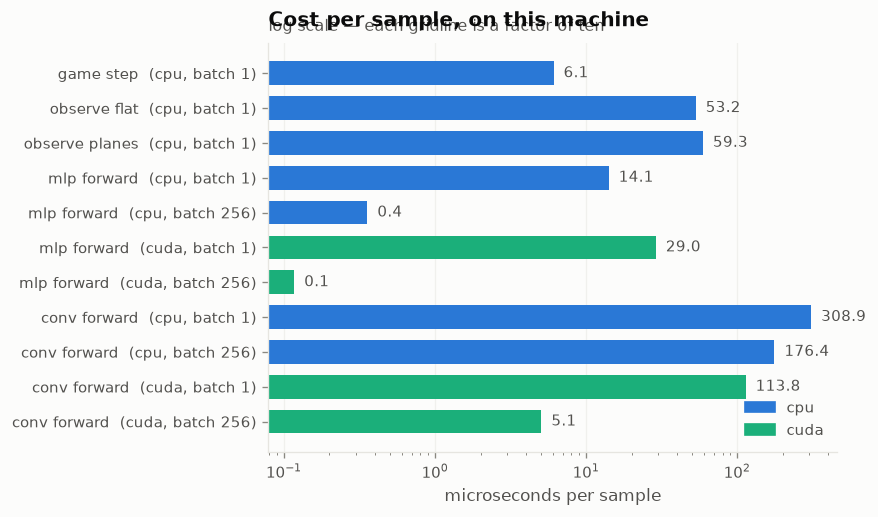

one game step + one planes observation: 65 us, all of it Python

mlp forward   batch 256:  cpu     0.36 us/sample   cuda   0.12 us/sample   (3x)
conv forward  batch 256:  cpu   176.35 us/sample   cuda   5.06 us/sample   (35x)


In [3]:
fig, ax = new_figure(height=4.2)

labels = [f"{r.op}  ({r.device}, batch {r.batch})" for r in profile.itertuples()]
colours = [colour_for("dqn") if r.device == "cuda" else colour_for("ga")
           for r in profile.itertuples()]
y = np.arange(len(profile))
ax.barh(y, profile["us_per_sample"], color=colours, height=0.68)
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xscale("log")
for i, value in enumerate(profile["us_per_sample"]):
    ax.annotate(f"{value:,.1f}", (value, i), textcoords="offset points",
                xytext=(6, 0), va="center", fontsize=9, color=INK_SOFT)

handles = [plt.Rectangle((0, 0), 1, 1, color=colour_for("ga")),
           plt.Rectangle((0, 0), 1, 1, color=colour_for("dqn"))]
ax.legend(handles, ["cpu", "cuda"], loc="lower right")
finish(ax, title="Cost per sample, on this machine",
       subtitle="log scale — each gridline is a factor of ten",
       xlabel="microseconds per sample", legend=False)
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
plt.show()

batched = profile[profile["batch"] == 256].set_index(["op", "device"])["us_per_sample"]
env_cost = profile.loc[profile["op"] == "game step", "us_per_sample"].iloc[0]
env_cost += profile.loc[profile["op"] == "observe planes", "us_per_sample"].iloc[0]

print(f"one game step + one planes observation: {env_cost:,.0f} us, all of it Python\n")
for op in ("mlp forward", "conv forward"):
    line = f"{op:13s} batch 256:  cpu {batched[(op, 'cpu')]:8.2f} us/sample"
    if DEVICE == "cuda":
        speedup = batched[(op, "cpu")] / batched[(op, "cuda")]
        line += f"   cuda {batched[(op, 'cuda')]:6.2f} us/sample   ({speedup:.0f}x)"
    print(line)

Read the chart, not the folklore. The pattern you should expect:

* **The MLP is free either way.** At a hundredth the cost of a game step, moving it to
  the GPU changes nothing you can measure — and at batch 1 the GPU is often *slower*,
  because a kernel launch costs more than the arithmetic it carries. This is why
  `train/dqn.py` still defaults to `cpu`.
* **The conv is the opposite.** It is expensive enough that batching it on the GPU is a
  large win, and that win only appears at a real batch size. A conv at batch 1 wastes
  the device almost entirely.

The lesson generalises: **a GPU is a throughput device, so it pays only when you have
made the work batchy.** That is the reason `PLANES` sets `batch=256` and the flat
default is 64.

## 2. n-step returns

At `n_step=1`, one transition teaches the network about one decision: the reward you got,
plus a guess about everything after. A snake that traps itself and dies ten ticks later
learns only that the *last* state was fatal; the move that actually did it has to wait
for ten more rounds of bootstrapping before any of that news reaches it.

At `n_step=3`, each transition carries three real rewards before it starts guessing, so
the news travels three times faster. The cost is bias: those intermediate actions came
from an older, more exploratory policy, and nothing here corrects for it. Bias grows with
n, so the curve should improve and then turn back down. **Where it turns is an empirical
question about this game, which is why we measure it rather than copy 3 from a paper.**

One prediction worth committing to before looking: **Snake's reward is dense.** Food, a
per-tick survival bonus and a death penalty all arrive continuously, so there is little
delayed credit for n-step to rescue — while the bias is charged in full. Expect a modest
effect at best and a clear decline at large n. Connect Four is the opposite case, with a
single reward forty plies from the opening, and is where this should actually pay.

Both sweeps here use the flat encoding, because it is cheap and the question is about the
learning rule rather than the observation.

In [4]:
nstep_rows = sweep(
    "dqn", "snake", "n_step", [1, 2, 3, 5, 8],
    players=2, episodes=EPISODES, arena_games=ARENA_GAMES, prefix="opt-nstep",
)
nstep = pd.DataFrame(nstep_rows)
nstep[["n_step", "model", "train_seconds", "mean_score", "stderr", "win_rate"]].round(3)

training opt-nstep-1 …  10.7s train · score    18.03 ± 1.87 · win 98.2%
training opt-nstep-2 …   9.9s train · score    18.46 ± 1.74 · win 97.8%
training opt-nstep-3 …   9.9s train · score    16.93 ± 1.67 · win 96.2%
training opt-nstep-5 …   9.9s train · score    14.03 ± 1.65 · win 95.8%
training opt-nstep-8 …  10.1s train · score    10.10 ± 1.52 · win 92.5%


,n_step,model,train_seconds,mean_score,stderr,win_rate
0,1,opt-nstep-1,10.7,18.033,0.952,0.982
1,2,opt-nstep-2,9.9,18.455,0.886,0.978
2,3,opt-nstep-3,9.9,16.927,0.854,0.962
3,5,opt-nstep-5,9.9,14.029,0.842,0.958
4,8,opt-nstep-8,10.1,10.104,0.777,0.925


In [5]:
# The control. Same configuration as n_step=1 above, only the seed changes, so
# any spread is pure run-to-run variance. Anything in section 2 that lands
# inside this band is not evidence of anything.
seed_rows = sweep(
    "dqn", "snake", "seed", list(range(SEED_REPLICATES)),
    players=2, episodes=EPISODES, arena_games=ARENA_GAMES, n_step=1,
    prefix="opt-seed",
)
seeds = pd.DataFrame(seed_rows)
band_low, band_high = seeds["mean_score"].min(), seeds["mean_score"].max()

print(f"\nseed-only band at n_step=1: {band_low:.2f} to {band_high:.2f} "
      f"(spread {band_high - band_low:.2f}, sd {seeds['mean_score'].std():.2f})")

def verdict(row):
    """Where a setting sits relative to the seed band. Inside means no evidence."""
    if row["mean_score"] > band_high:
        return "above band"
    if row["mean_score"] < band_low:
        return "BELOW band"
    return "inside — no evidence"


nstep["verdict"] = nstep.apply(verdict, axis=1)
print()
for row in nstep.itertuples():
    print(f"  n_step={int(row.n_step)}: {row.mean_score:6.2f}   {row.verdict}")

BEST_N = int(nstep.loc[nstep["mean_score"].idxmax(), "n_step"])
print(f"\nbest n_step by mean score: {BEST_N}")
print("\nRead the losses as carefully as the wins. A setting far BELOW the band"
      " is as much of a finding as one above it, and with n-step it is the"
      " expected one: that is the off-policy bias arriving.")

training opt-seed-0 …   9.8s train · score    18.03 ± 1.87 · win 98.2%
training opt-seed-1 …  10.2s train · score    11.60 ± 1.42 · win 93.8%
training opt-seed-2 …  10.0s train · score    14.27 ± 1.65 · win 97.0%
training opt-seed-3 …   9.9s train · score    11.64 ± 1.36 · win 95.7%

seed-only band at n_step=1: 11.60 to 18.03 (spread 6.43, sd 3.03)

  n_step=1:  18.03   inside — no evidence
  n_step=2:  18.46   above band
  n_step=3:  16.93   inside — no evidence
  n_step=5:  14.03   inside — no evidence
  n_step=8:  10.10   BELOW band

best n_step by mean score: 2

Read the losses as carefully as the wins. A setting far BELOW the band is as much of a finding as one above it, and with n-step it is the expected one: that is the off-policy bias arriving.


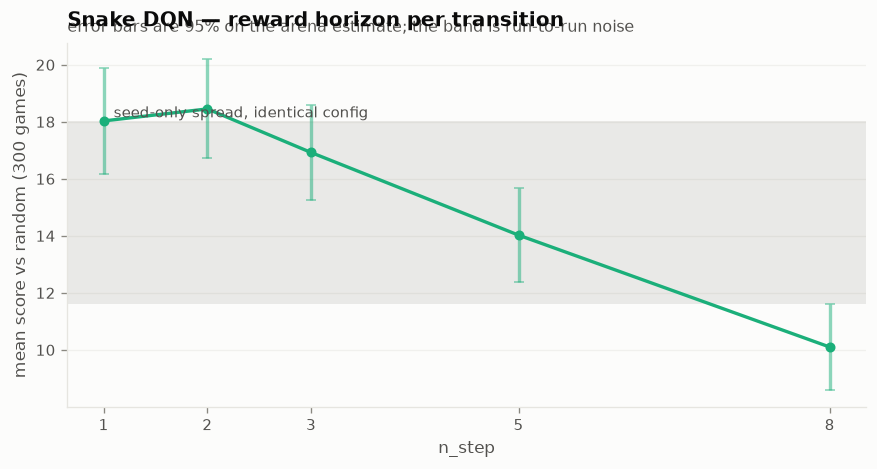

In [6]:
fig, ax = new_figure()

ax.axhspan(band_low, band_high, color=INK_FAINT, alpha=0.16, linewidth=0)
ax.text(nstep["n_step"].iloc[0], band_high, "  seed-only spread, identical config",
        va="bottom", fontsize=9, color=INK_SOFT)

ax.plot(nstep["n_step"], nstep["mean_score"], color=colour_for("dqn"),
        marker="o", label="varying n_step")
ax.errorbar(nstep["n_step"], nstep["mean_score"], yerr=1.96 * nstep["stderr"],
            fmt="none", ecolor=colour_for("dqn"), alpha=0.5, capsize=3)
ax.set_xticks(nstep["n_step"], [str(int(n)) for n in nstep["n_step"]])

finish(ax, title="Snake DQN — reward horizon per transition",
       subtitle="error bars are 95% on the arena estimate; the band is run-to-run noise",
       xlabel="n_step", ylabel=f"mean score vs random ({ARENA_GAMES} games)")
plt.show()

## 3. Hand-crafted features versus the raw board

Now the observation. `flat` is nineteen numbers a human chose: danger in each direction,
a flood-filled free-space estimate, a vector to the nearest food. `planes` is the board
as eight binary 12x12 layers — own head, own body, own tail, enemy head, enemy body,
enemy tail, food, and an all-ones mask whose only job is to make the convolution's zero
padding read as *wall* rather than *empty space*.

Why a convolution rather than a wider MLP over the same grid: convolution is
**translation-equivariant**. It learns "food one cell to my left" once, instead of
learning it separately for each of 144 board positions. That is an enormous reduction in
what has to be discovered from data, and it is the entire argument for the architecture.

Note that `planes` **appends the flat vector** rather than replacing it. The flood fill
in `free_space` is a global property of the board, and a three-layer tower of 3x3 filters
sees only a 7-cell window — it cannot compute that no matter how long it trains. Feeding
both is standard, and usually beats either alone.

Everything except the encoding is held constant, including the buffer and batch size, so
the MLP here is not the tuned default from `sweeps.ipynb` — it is the MLP under the
conv's settings. That is the comparison that isolates the encoding.

In [ ]:
encoding_rows = sweep(
    "dqn", "snake", "encoding", ["flat", "planes"],
    players=2, episodes=PLANES_EPISODES, arena_games=ARENA_GAMES,
    n_step=BEST_N, prefix="opt-enc", **PLANES,
)
encodings = pd.DataFrame(encoding_rows)
encodings[["encoding", "model", "params", "train_seconds",
           "mean_score", "stderr", "win_rate"]].round(3)

training opt-enc-flat …  14.6s train · score    21.49 ± 2.30 · win 99.0%
training opt-enc-planes … 

In [ ]:
flat_row = encodings[encodings["encoding"] == "flat"].iloc[0]
planes_row = encodings[encodings["encoding"] == "planes"].iloc[0]

fig, ax = new_figure(height=3.2)
ax.barh([0, 1], [flat_row["mean_score"], planes_row["mean_score"]],
        xerr=[1.96 * flat_row["stderr"], 1.96 * planes_row["stderr"]],
        color=[colour_for("ga"), colour_for("dqn")], height=0.5,
        error_kw={"ecolor": INK_SOFT, "capsize": 4})
ax.set_yticks([0, 1], [f"flat\n{flat_row['params']:,} params",
                       f"planes + conv\n{planes_row['params']:,} params"])
ax.invert_yaxis()
finish(ax, title="Snake DQN — observation encoding",
       subtitle=f"same n_step, buffer, batch and episode budget · {ARENA_GAMES} games",
       xlabel="mean score vs random")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
plt.show()

gap = planes_row["mean_score"] - flat_row["mean_score"]
apart = separable(flat_row["score_low"], flat_row["score_high"],
                  planes_row["score_low"], planes_row["score_high"])
print(f"planes − flat: {gap:+.2f}   intervals {'do not overlap' if apart else 'overlap'}")
print(f"parameters: {planes_row['params'] / flat_row['params']:.0f}x  ·  "
      f"training time: {planes_row['train_seconds'] / flat_row['train_seconds']:.1f}x")
if not apart:
    print("\nOverlapping intervals mean this run cannot rank them. That is a real "
          "result, not a failed one:\nat this episode budget the extra capacity has "
          "not paid for itself yet. Raise PLANES_EPISODES\nbefore concluding the "
          "encoding does not help — a conv needs more data, not just more time.")

## 4. Does a bigger network help?

The question you actually asked. `channels` is the width of the conv tower and the main
capacity lever; everything else is held fixed.

Expect this curve to be **flatter than it feels like it should be**, and quite possibly
to bend downward at the top. Supervised learning scales beautifully with model size
because the data is fixed and abundant. RL generates its own data, so the binding
constraint is sample efficiency, and a larger network needs *more* experience to fit
while being less stable on the way there. At a fixed episode budget, capacity past some
point buys nothing and costs wall-clock.

That is why "make the model bigger" belongs *after* "give it a better observation" and
"give it more environment throughput" in the order of things to try.

In [ ]:
capacity_rows = sweep(
    "dqn", "snake", "channels", [16, 32, 64, 128],
    players=2, episodes=PLANES_EPISODES, arena_games=ARENA_GAMES,
    n_step=BEST_N, encoding="planes", prefix="opt-ch",
    **{k: v for k, v in PLANES.items() if k != "channels"},
)
capacity = pd.DataFrame(capacity_rows)
capacity[["channels", "params", "train_seconds", "mean_score", "stderr",
          "win_rate"]].round(3)

In [ ]:
fig, ax = new_figure()

ax.axhspan(band_low, band_high, color=INK_FAINT, alpha=0.16, linewidth=0)
ax.text(capacity["params"].min(), band_high, "  flat-MLP seed-only spread, for scale",
        va="bottom", fontsize=9, color=INK_SOFT)

ax.plot(capacity["params"], capacity["mean_score"], color=colour_for("dqn"), marker="o")
ax.errorbar(capacity["params"], capacity["mean_score"],
            yerr=1.96 * capacity["stderr"], fmt="none",
            ecolor=colour_for("dqn"), alpha=0.5, capsize=3)
ax.set_xscale("log")
for row in capacity.itertuples():
    ax.annotate(f"{row.channels}ch\n{row.train_seconds:.0f}s",
                (row.params, row.mean_score), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=9, color=INK_SOFT)

finish(ax, title="Snake conv DQN — capacity against payoff",
       subtitle="at a fixed episode budget, so this is capacity per unit of experience",
       xlabel="trainable parameters (log)",
       ylabel=f"mean score vs random ({ARENA_GAMES} games)")
plt.show()

best = capacity.loc[capacity["mean_score"].idxmax()]
biggest = capacity.loc[capacity["params"].idxmax()]
print(f"best: {int(best.channels)} channels, {best.params:,} params, "
      f"{best.mean_score:.2f}")
print(f"largest: {int(biggest.channels)} channels, {biggest.params:,} params, "
      f"{biggest.mean_score:.2f}, {biggest.train_seconds / best.train_seconds:.1f}x "
      f"the training time of the best")

## 5. What is a training run actually waiting on?

Section 1 timed the pieces in isolation. This runs the real loop and splits the wall
clock into **collecting** experience (Python: game steps, observations, one forward pass
per decision at batch 1) and **updating** the network (batched forward and backward).

This is the measurement that tells you what to optimise next, and it is the one people
skip. Read `collect_%` before deciding anything: it is the **ceiling on what a faster
collector can return**, and section 6 spends that budget to see how much of it is real.

In [ ]:
def decompose(episodes=150, **overrides):
    """Time collection and updates separately for one training configuration."""
    args = SimpleNamespace(game="snake",
                           **{**DEFAULTS, "players": 2, "quiet": True, **overrides})
    g = make_game("snake", num_players=2)
    make_net, obs_size, dtype = build_for(g, args)
    net, target = make_net().to(args.device), make_net().to(args.device)
    target.load_state_dict(net.state_dict())
    opt = torch.optim.Adam(net.parameters(), lr=args.lr)
    learner = DQNAgent(net, epsilon=0.2, encoding=args.encoding)
    buffer = ReplayBuffer(args.buffer, obs_size, seed=0, dtype=dtype)
    rng = random.Random(0)

    collect_s = update_s = 0.0
    updates = 0
    for episode in range(episodes):
        started = time.perf_counter()
        collect_episode(g, learner, "random", rng.randrange(2**31), buffer,
                        episode % 2, n_step=args.n_step, gamma=args.gamma)
        collect_s += time.perf_counter() - started

        if buffer.size >= args.warmup:
            started = time.perf_counter()
            for _ in range(args.updates_per_episode):
                train_step(net, target, opt, buffer, args.batch, args.gamma,
                           g.num_actions)
                updates += 1
            if args.device == "cuda":
                torch.cuda.synchronize()
            update_s += time.perf_counter() - started

    return {"collect_s": collect_s, "update_s": update_s, "updates": updates}


configs = {"flat / cpu": dict(encoding="flat", device="cpu", batch=64, warmup=200)}
if DEVICE == "cuda":
    configs["planes / cpu"] = dict(encoding="planes", device="cpu", batch=256,
                                   buffer=30_000, warmup=200)
    configs["planes / cuda"] = dict(encoding="planes", device="cuda", batch=256,
                                    buffer=30_000, warmup=200)
else:
    configs["planes / cpu"] = dict(encoding="planes", device="cpu", batch=256,
                                   buffer=30_000, warmup=200)

split = pd.DataFrame(
    [{"config": name, **decompose(**kwargs)} for name, kwargs in configs.items()]
).set_index("config")
split["total_s"] = split["collect_s"] + split["update_s"]
split["collect_%"] = 100 * split["collect_s"] / split["total_s"]
split.round(2)

In [ ]:
fig, ax = new_figure(height=3.4)

y = np.arange(len(split))
ax.barh(y, split["collect_s"], color=colour_for("ga"), height=0.55, label="collect")
ax.barh(y, split["update_s"], left=split["collect_s"], color=colour_for("dqn"),
        height=0.55, label="update")
ax.set_yticks(y, split.index)
ax.invert_yaxis()
# Indexed by label rather than by itertuples: "collect_%" is not a valid Python
# identifier, so itertuples would silently rename it to a positional field.
for i, label in enumerate(split.index):
    ax.annotate(f"{split.loc[label, 'collect_%']:.0f}% collecting",
                (split.loc[label, "total_s"], i), textcoords="offset points",
                xytext=(8, 0), va="center", fontsize=9, color=INK_SOFT)
ax.set_xlim(0, split["total_s"].max() * 1.35)

finish(ax, title="Where a training run spends its wall clock",
       subtitle="150 episodes each, same loop the trainer runs",
       xlabel="seconds")
ax.grid(axis="x", visible=True)
ax.grid(axis="y", visible=False)
plt.show()

for name, row in split.iterrows():
    print(f"{name:14s} {row['total_s']:6.1f}s total  ·  "
          f"{row['collect_%']:4.0f}% collecting  ·  "
          f"{1000 * row['update_s'] / max(row['updates'], 1):5.2f} ms per update")

Whatever the split is on your machine, the number to act on is **`collect_%`** — and the
discipline is to read it as a *budget* before spending any effort. If collection is 10% of
the clock, then making collection instantaneous returns 10%, and no amount of cleverness
in the collector beats that bound. This is Amdahl's law, and it is the most commonly
ignored number in performance work.

Section 6 does the experiment anyway, because a bound is not a measurement.

## 6. Vectorised collection

`--envs N` plays N episodes concurrently. The game does not get faster — stepping N Python
games costs exactly N times stepping one. What changes is that every agent is asked for
**all its pending decisions at once**, so the network does one forward pass over N
positions instead of N passes over one. At batch 1 a GPU spends longer launching the
kernel than running it; this is the difference between using the device and owning it.

`--envs` is a pure throughput knob: same episodes, same gradient steps, same replay ratio.
`tests/test_vectorised.py` pins that down differentially — batched collection must store
exactly the transitions serial collection would.

First, does it speed up the thing it targets?

In [ ]:
class _Counter:
    """A buffer that only counts, so this measures collection and nothing else."""

    def __init__(self):
        self.size = 0

    def add(self, *args, **kwargs):
        self.size += 1


def throughput(learner, envs, episodes=256, num_players=2):
    """Transitions per second of pure collection, no gradient steps at all."""
    g = make_game("snake", num_players=num_players)
    buffer, rng, done = _Counter(), random.Random(0), 0
    started = time.perf_counter()
    while done < episodes:
        batch = min(envs, episodes - done)
        collect_batch(
            g, learner, "random",
            [rng.randrange(2**31) for _ in range(batch)], buffer,
            [(done + k) % num_players for k in range(batch)],
        )
        done += batch
    if learner.net.device.type == "cuda":
        torch.cuda.synchronize()
    return buffer.size / (time.perf_counter() - started)


learners = {
    "flat MLP / cpu": DQNAgent(MLP([game.obs_size, 128, 128, 4]), epsilon=0.05),
    "conv / cpu": DQNAgent(ConvNet(grid, scalars, 4), epsilon=0.05, encoding="planes"),
}
if DEVICE == "cuda":
    learners["conv / cuda"] = DQNAgent(
        ConvNet(grid, scalars, 4).to("cuda"), epsilon=0.05, encoding="planes")

ENV_COUNTS = [1, 4, 16, 64, 256]
rates = pd.DataFrame(
    {label: [throughput(learner, n) for n in ENV_COUNTS]
     for label, learner in learners.items()},
    index=pd.Index(ENV_COUNTS, name="envs"),
)
rates.round(0)

In [ ]:
fig, ax = new_figure()

for label in rates.columns:
    speedup = rates[label] / rates[label].iloc[0]
    ax.plot(rates.index, speedup, marker="o", color=colour_for(label), label=label)

ax.axhline(1.0, color=INK_FAINT, linewidth=1, linestyle="--")
ax.set_xscale("log", base=2)
ax.set_xticks(ENV_COUNTS, [str(n) for n in ENV_COUNTS])
finish(ax, title="Collection throughput against concurrent environments",
       subtitle="relative to envs=1; higher is better",
       xlabel="envs", ylabel="speedup on collection")
plt.show()

for label in rates.columns:
    best = rates[label].idxmax()
    print(f"{label:16s} peak {rates[label].max():8.0f} transitions/s at envs={best:<4d}"
          f"({rates[label].max() / rates[label].iloc[0]:.2f}x over envs=1)")

The GPU conv is the one that benefits, and it keeps climbing where both CPU variants peak
early and then **decline** — a CPU convolution at batch 256 is no faster per sample than at
batch 1, so the extra bookkeeping is pure loss. That is the same fact section 1 measured,
showing up from the other side.

Now the question that matters: does it make *training* faster? `updates_per_episode` sets
the replay ratio — gradient steps bought per episode of fresh experience — and it decides
how much of the clock collection was ever responsible for.

In [ ]:
def end_to_end(envs, episodes=200, **overrides):
    """Wall clock for a fixed episode budget at a given `envs`."""
    started = time.perf_counter()
    train_dqn("snake", players=2, envs=envs, episodes=episodes,
              eval_every=episodes, eval_games=2, save=False, quiet=True,
              **overrides)
    return time.perf_counter() - started


fixed = dict(encoding="planes", device=DEVICE, batch=256, buffer=20_000,
             warmup=200, channels=32, blocks=2)

rows = []
for updates in (8, 4, 2, 1):
    one = end_to_end(1, updates_per_episode=updates, **fixed)
    many = end_to_end(64, updates_per_episode=updates, **fixed)
    rows.append({"updates_per_episode": updates, "envs=1": one,
                 "envs=64": many, "speedup": one / many})

wall = pd.DataFrame(rows).set_index("updates_per_episode")
wall.round(2)

Read this against `collect_%` from section 5, and it should be unsurprising: collection was
a small share of the clock, so removing all of it could only ever return that share. At a
high replay ratio the speedup is at or below **1.0x** — the batching overhead is real and
there is nothing for it to buy.

**This is a negative result for the wall-clock motivation, and it is the honest headline.**
Training here is update-bound at every sane replay ratio, and a faster collector cannot fix
that. Two things it does earn anyway:

* It makes a **lower replay ratio affordable**, and fewer gradient steps per fresh
  transition is usually better for final performance, not merely faster. That is a change
  in what you can reasonably run, which no timing table shows.
* It moves the bottleneck onto **pure-Python game stepping**. At `envs=128` the flat/cpu
  collector runs at roughly 83% of the ceiling set by `step` plus `observe` alone. Getting
  past that needs Snake's dynamics reimplemented over batched arrays — a much larger change
  than this one, and only worth it if collection ever becomes the thing to optimise.

The general lesson is the one from section 4 in a different costume: **measure the share
before optimising the part.** An honest 2.8x on 10% of the work is 1.03x, and the only way
to know that in advance was to look.

## 7. Head to head

Scores against `random` are a screening tool — they separate an agent that can play from
one that cannot, and stop discriminating above that. The models here can all play, so the
last word goes to the arena: every model against every other, seats rotated, same seeds
replayed for every pairing.

Watch for the usual disagreement. **Ranking by score-vs-random and ranking by head-to-head
win rate are not the same ordering**, and when they disagree the head-to-head is the one
that answers "which model is better".

In [ ]:
contenders = [
    "ga",                                                    # curated GA baseline
    "dqn",                                                   # curated DQN baseline
    str(nstep.loc[nstep["mean_score"].idxmax(), "model"]),   # best n_step, flat
    str(encodings.loc[encodings["encoding"] == "planes", "model"].iloc[0]),
    str(capacity.loc[capacity["mean_score"].idxmax(), "model"]),
    "random",
]
contenders = list(dict.fromkeys(contenders))
print("\n".join(f"  {c}" for c in contenders))

results = round_robin("snake", contenders, games=ARENA_GAMES, players=2)

# orient="index" matters: `win_rate` is {a: {b: a's rate against b}}, and plain
# pd.DataFrame() on a dict-of-dicts puts the OUTER keys on the columns, which
# silently transposes the matrix and reverses every ranking below.
grid_wins = (pd.DataFrame.from_dict(results["win_rate"], orient="index")
             .loc[contenders, contenders])
(grid_wins * 100).round(1)

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
values = grid_wins.to_numpy(dtype=float)
image = ax.imshow(values, cmap=diverging_cmap(), vmin=0.0, vmax=1.0)

ax.set_xticks(range(len(contenders)), contenders, rotation=35, ha="right")
ax.set_yticks(range(len(contenders)), contenders)
for i in range(len(contenders)):
    for j in range(len(contenders)):
        if i == j:
            continue
        low, high = results["interval"][contenders[i]][contenders[j]]
        decided = low > 0.5 or high < 0.5
        ax.text(j, i, f"{values[i, j]:.0%}", ha="center", va="center", fontsize=9,
                color="white" if abs(values[i, j] - 0.5) > 0.28 else INK,
                fontweight="bold" if decided else "normal")

ax.set_title("Row's win rate against column", loc="left", pad=10)
ax.text(0.0, 1.02, f"{ARENA_GAMES} games per pairing · bold where the 95% interval "
                   "excludes an even match",
        transform=ax.transAxes, fontsize=9.5, color=INK_SOFT, va="bottom")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="win rate")
plt.show()

standings = (grid_wins.mean(axis=1, skipna=True)
             .sort_values(ascending=False).rename("mean win rate"))
print(standings.round(3).to_string())

## 8. What this leaves you with

Read your own numbers rather than these notes, but the shape of the conclusion is usually:

* **n-step is cheap but not free, and Snake is the wrong game for it.** It costs nothing
  at run time and moves reward backwards faster — but Snake's reward is already dense, so
  there is little to rescue, and the off-policy bias at large n is a real, measurable loss.
  If sections 2 shows small n inside the band and large n below it, that is the tradeoff
  working exactly as advertised. Try the same sweep on `connect4`, where the only reward
  arrives forty plies in; that is where the win should be.
* **The conv needs a budget the MLP does not, and under `FAST` it does not get one.** It
  has one to two orders of magnitude more parameters and has to *learn* a representation
  that the flat encoding was handed for free — nineteen numbers that already encode
  danger, free space and food direction, distilled from someone who knows the game. A few
  thousand episodes is nowhere near enough to rediscover that from raw pixels-equivalent,
  so expect section 3 to come out clearly *negative* at this budget. That is the correct
  result, not a broken one, and it is the single most important thing to understand about
  scaling up a model: **capacity is a loan against future data, and it is expensive until
  the data arrives.** Rerun with `FAST = False` before drawing any conclusion about which
  encoding is better.
* **Capacity is the last lever, not the first.** Section 4 usually shows it saturating
  well before the biggest model in the sweep.

Things worth trying next, roughly in order of payoff for the effort:

1. **Egocentric planes.** Rotate the board so the snake always faces up. The board is
   square, so this costs nothing in size, and it collapses four directional cases into
   one. The catch is that the action space rotates with it, so `legal_actions` and the
   Q-head have to agree about which frame they are in — that is the fiddly part, and the
   reason it is not in this notebook already.
2. **Prioritised replay.** Sample transitions in proportion to their TD error, so the
   surprising ones get revisited. Roughly forty lines on top of `ReplayBuffer`.
3. **Vectorised environments,** if section 5 says collection dominates. The largest change
   here, and the only one that makes the GPU the bottleneck rather than Python.
4. **A dueling head.** Split Q into a state value and a per-action advantage. Ten lines in
   `ConvNet`, and it helps most in states where the action choice barely matters — which
   in Snake is most of them.

Each of those is one change, measured against the seed band in section 2. That is the
whole method: one thing at a time, against a control, with an interval on it.